# 🧠 1. Salud: Ideación / Intento (VARIABLE CENTRAL)

👉 Este es el corazón del análisis. Identificaremos localidades críticas, grupos poblacionales en riesgo y causas reportadas.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuracion visual
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

### Carga de Datos Preprocesados

In [5]:
PROCESSED_DIR = '../../01_datos/processed'
file_path = os.path.join(PROCESSED_DIR, 'p_salud_ideacion.xlsx')
df_ideacion = pd.read_excel(file_path)
print(f'Total de registros cargados: {len(df_ideacion):,}')
display(df_ideacion.head())

Total de registros cargados: 254,251


,ano_notificacion,codigo_localidadresidencia,localidad_residencia,nombre_upz,ciclovital,clasificaciondelaconducta,sexo,edad,niveleducativo,enfermedades_dolorosas,maltrato_sexual,muerte_familiar,conflicto_pareja,problemas_economicos,esc_educ,problemas_juridicos,problemas_laborales,suicidio_amigo,poblacion_diferencial
0,2023,15.0,Antonio Nariño,CIUDAD JARDIN,>60 Vejez,Intento de Suicidio,Hombre,71,3. Primaria incompleta,0,0,0,1,0,0,0,0,0,Ninguna
1,2022,4.0,San Cristóbal,LA GLORIA,>60 Vejez,Intento de Suicidio,Hombre,71,4. Primaria completa,1,0,1,0,0,0,0,0,0,Ninguna
2,2025,19.0,Ciudad Bolívar,LUCERO,>60 Vejez,Ideación suicida,Mujer,71,5. Secundaria incompleta,0,1,0,1,1,0,0,0,0,Ninguna
3,2023,18.0,Rafael Uribe Uribe,MARRUECOS,>60 Vejez,Ideación suicida,Hombre,71,3. Primaria incompleta,1,0,0,1,1,0,0,1,0,Ninguna
4,2017,13.0,Teusaquillo,QUINTA PAREDES,>60 Vejez,Ideación suicida,Mujer,71,10. Universidad completa,0,0,0,0,0,0,0,0,0,Otra


## 📈 Tendencia
**¿Los casos aumentan por año? ¿Hay picos en ciertos años?**

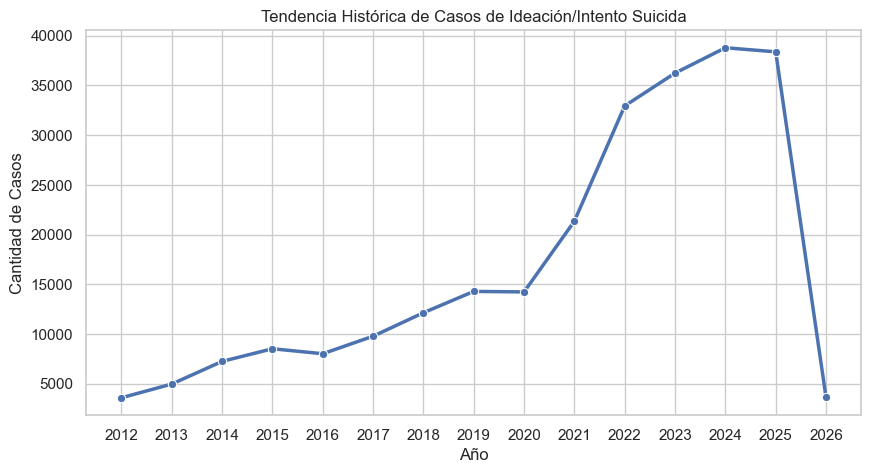

In [6]:
# Validamos la columna temporal
if 'ano_notificacion' in df_ideacion.columns:
    tendencia = df_ideacion['ano_notificacion'].value_counts().sort_index()
    plt.figure(figsize=(10,5))
    sns.lineplot(x=tendencia.index, y=tendencia.values, marker='o', linewidth=2.5)
    plt.title('Tendencia Histórica de Casos de Ideación/Intento Suicida')
    plt.xlabel('Año')
    plt.ylabel('Cantidad de Casos')
    plt.xticks(tendencia.index)
    plt.show()
else:
    print('Columna de año no encontrada.')

## 📍 Territorial
**¿Qué localidades tienen más casos? ¿Hay concentración clara o está disperso?**

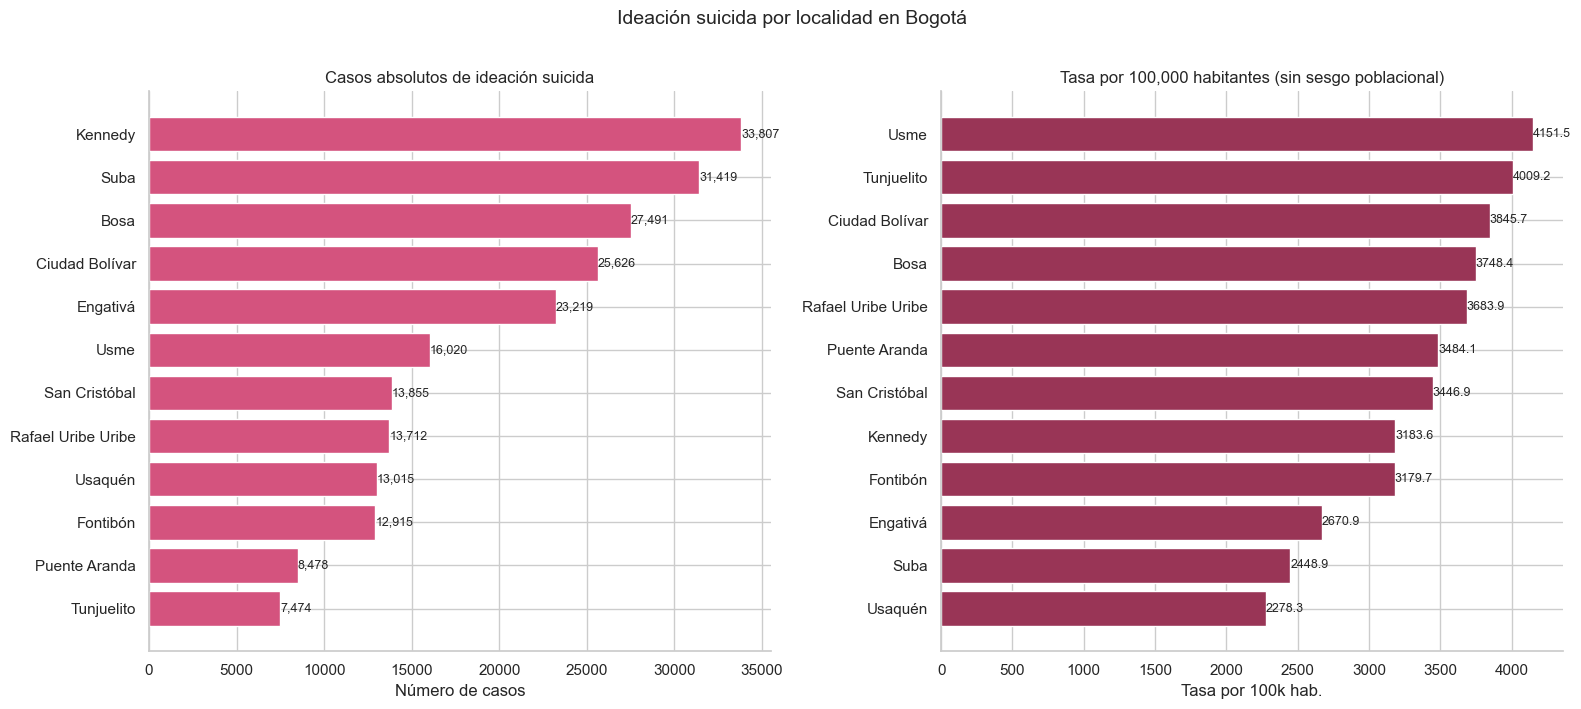


Las 3 localidades con mayor TASA concentran el 19.3% de los casos.
         localidad  casos  poblacion   tasa_100k
              Usme  16020     385888 4151.463637
        Tunjuelito   7474     186419 4009.247984
    Ciudad Bolívar  25626     666350 3845.726720
              Bosa  27491     733398 3748.442183
Rafael Uribe Uribe  13712     372217 3683.872580
     Puente Aranda   8478     243334 3484.100044
     San Cristóbal  13855     401960 3446.860384
           Kennedy  33807    1061902 3183.627114
          Fontibón  12915     406174 3179.671766
          Engativá  23219     869327 2670.916698
              Suba  31419    1282978 2448.911829
           Usaquén  13015     571268 2278.265193


In [13]:
import unicodedata
import os

def limpiar(s):
    return unicodedata.normalize('NFKD', str(s)).encode('ascii', 'ignore').decode().strip().lower()

df_pob = pd.read_csv(os.path.join(PROCESSED_DIR, 'p_poblacion_bogota.csv'))

col_loc = 'localidad_residencia'

conteo = df_ideacion[col_loc].value_counts().reset_index()
conteo.columns = ['localidad', 'casos']
conteo['key'] = conteo['localidad'].apply(limpiar)
df_pob['key'] = df_pob['localidad'].apply(limpiar)

df_merge = conteo.merge(df_pob[['key','poblacion']], on='key', how='left')
df_merge['tasa_100k'] = df_merge['casos'] / df_merge['poblacion'] * 100000
df_merge = df_merge.dropna(subset=['tasa_100k'])

top12 = df_merge.sort_values('casos', ascending=False).head(12)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top12_abs = top12.sort_values('casos')
axes[0].barh(top12_abs['localidad'], top12_abs['casos'], color='#D4537E')
axes[0].set_title('Casos absolutos de ideación suicida', fontsize=12)
axes[0].set_xlabel('Número de casos')
for i, v in enumerate(top12_abs['casos']):
    axes[0].text(v + 10, i, f'{int(v):,}', va='center', fontsize=9)

top12_tasa = top12.sort_values('tasa_100k')
axes[1].barh(top12_tasa['localidad'], top12_tasa['tasa_100k'], color='#993556')
axes[1].set_title('Tasa por 100,000 habitantes (sin sesgo poblacional)', fontsize=12)
axes[1].set_xlabel('Tasa por 100k hab.')
for i, v in enumerate(top12_tasa['tasa_100k']):
    axes[1].text(v + 0.1, i, f'{v:.1f}', va='center', fontsize=9)

top3_pct = top12.sort_values('tasa_100k', ascending=False).head(3)['casos'].sum() / len(df_ideacion) * 100
plt.suptitle('Ideación suicida por localidad en Bogotá', fontsize=14, fontweight='500', y=1.01)
sns.despine()
plt.tight_layout()
plt.show()

print(f'\nLas 3 localidades con mayor TASA concentran el {top3_pct:.1f}% de los casos.')
print(top12.sort_values('tasa_100k', ascending=False)[['localidad','casos','poblacion','tasa_100k']].to_string(index=False))

In [10]:
print([c for c in df_ideacion.columns if 'local' in c.lower()])
print(df_ideacion['localidad_residencia'].value_counts().head(5))

['codigo_localidadresidencia', 'localidad_residencia']
localidad_residencia
Kennedy           33807
Suba              31419
Bosa              27491
Ciudad Bolívar    25626
Engativá          23219
Name: count, dtype: int64


## 👥 Perfil Poblacional
**¿Qué edades concentran más casos? ¿Diferencias por sexo?**

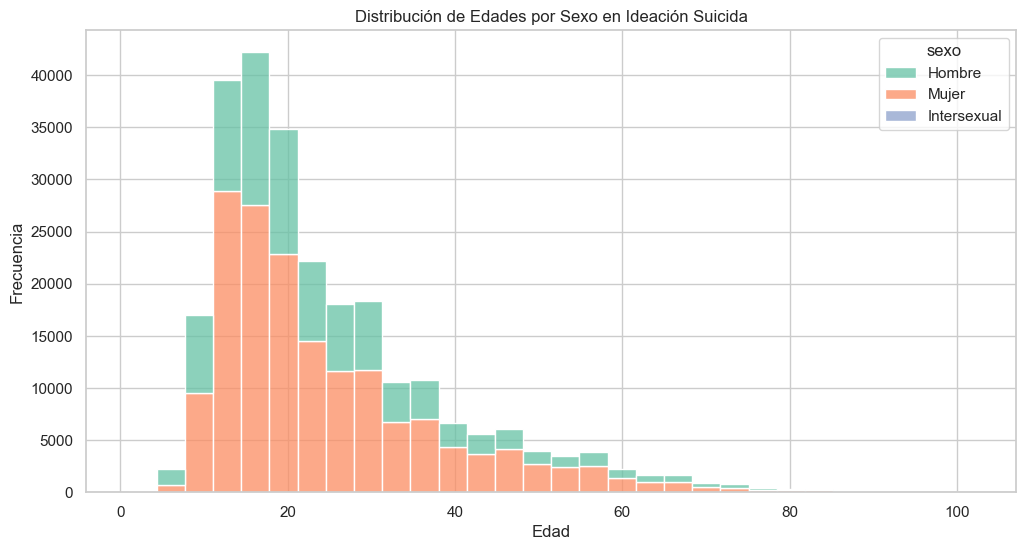

Análisis Rápido Edad/Sexo:
                count       mean   min    max
sexo                                         
Hombre        88249.0  24.909143   1.0   99.0
Intersexual       4.0  19.750000  16.0   24.0
Mujer        165998.0  24.617200   1.0  102.0


In [8]:
if 'edad' in df_ideacion.columns and 'sexo' in df_ideacion.columns:
    plt.figure(figsize=(12,6))
    sns.histplot(data=df_ideacion, x='edad', hue='sexo', multiple='stack', bins=30, palette='Set2')
    plt.title('Distribución de Edades por Sexo en Ideación Suicida')
    plt.xlabel('Edad')
    plt.ylabel('Frecuencia')
    plt.show()
    
    print('Análisis Rápido Edad/Sexo:')
    print(df_ideacion.groupby('sexo')['edad'].describe()[['count', 'mean', 'min', 'max']])

## ⚠️ Factores asociados
**¿Qué variables o causas aparecen más frecuentemente?**

C:\Users\Latitude\AppData\Local\Temp\ipykernel_31212\2358967873.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteos.values, y=conteos.index, palette='rocket')


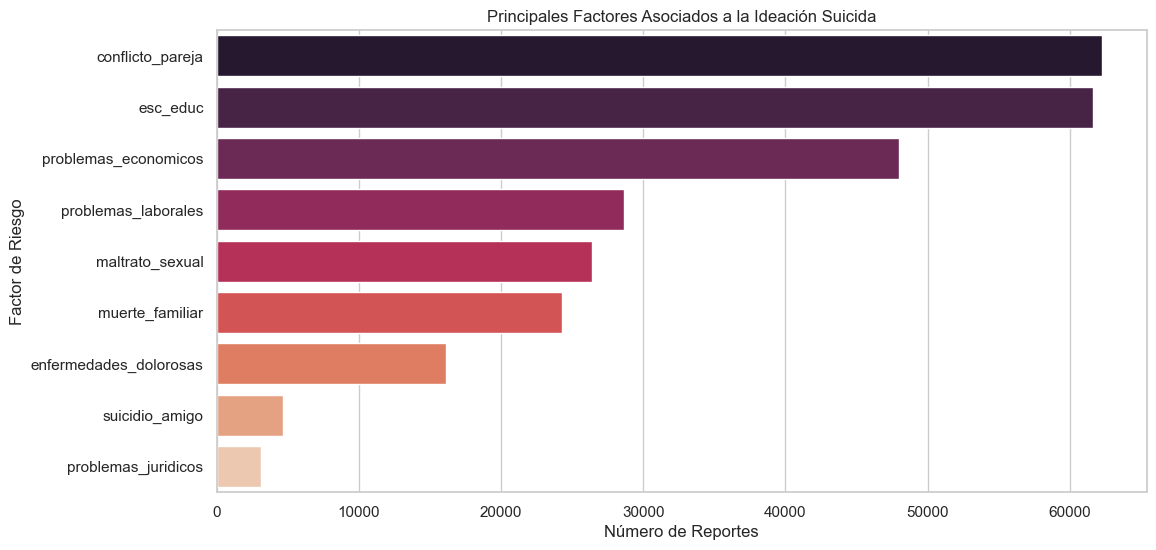

In [9]:
factores = ['enfermedades_dolorosas', 'maltrato_sexual', 'muerte_familiar', 'conflicto_pareja', 'problemas_economicos', 'esc_educ', 'problemas_juridicos', 'problemas_laborales', 'suicidio_amigo']

# Filtrar los factores que sí esten en la tabla
factores_presentes = [f for f in factores if f in df_ideacion.columns]
if factores_presentes:
    # Calculamos cuántas veces ocurre cada factor (asumiendo que 1 es sí/presente)
    conteos = df_ideacion[factores_presentes].sum().sort_values(ascending=False)
    
    plt.figure(figsize=(12,6))
    sns.barplot(x=conteos.values, y=conteos.index, palette='rocket')
    plt.title('Principales Factores Asociados a la Ideación Suicida')
    plt.xlabel('Número de Reportes')
    plt.ylabel('Factor de Riesgo')
    plt.show()
else:
    print('Las columnas de factores de riesgo no fueron detectadas con esos nombres específicos.')